**Import Important Libraries**

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    log_loss,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

**Libararies for Neural Network**

In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, log_loss, roc_auc_score
from sklearn.preprocessing import label_binarize

**Load Data set**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Text Mining/Reviews.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
df.head()
df.shape
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

**Keep the coloumns needed and drop missing rows**

In [ ]:
df = df[['Score', 'Summary', 'Text']]
df = df.dropna()
print(df.shape)
df.head()

(568427, 3)


,Score,Summary,Text
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,"""Delight"" says it all",This is a confection that has been around a fe...
3,2,Cough Medicine,If you are looking for the secret ingredient i...
4,5,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
df.isnull().sum()

,0
Score,0
Summary,0
Text,0


**Create the business target variable or sentiment labels**

Rule:

1–2 = negative

3 = neutral

4–5 = positive

In [ ]:
def sentiment(score):
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"

df["sentiment"] = df["Score"].apply(sentiment)
df["sentiment"].value_counts()

,count
sentiment,
positive,443777
negative,82012
neutral,42638


**Combination of Summnary and Full Review Text**

In [ ]:
df["review"] = df["Summary"].astype(str) + " " + df["Text"].astype(str)
df = df[['review', 'sentiment']]
df.head()

,review,sentiment
0,Good Quality Dog Food I have bought several of...,positive
1,Not as Advertised Product arrived labeled as J...,negative
2,"""Delight"" says it all This is a confection tha...",positive
3,Cough Medicine If you are looking for the secr...,negative
4,Great taffy Great taffy at a great price. The...,positive


In [ ]:
print(df.shape)

(568427, 2)


**Create Baseline Pipeline Data set**

In [ ]:
df_base = df.copy()

df_base["review"] = df_base["review"].str.lower().str.strip()

print("Baseline dataset shape:", df_base.shape)

Baseline dataset shape: (568427, 2)


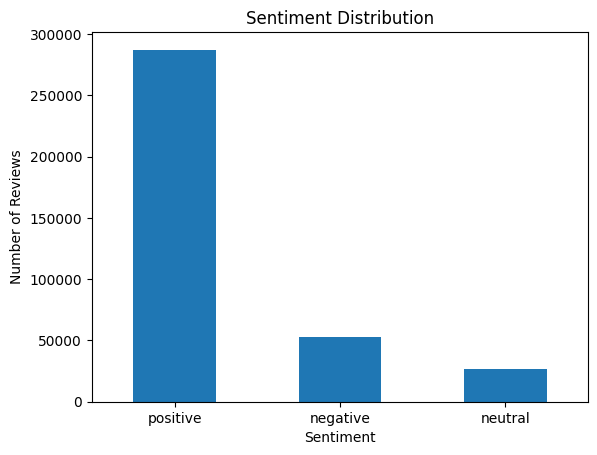

In [98]:


df["sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

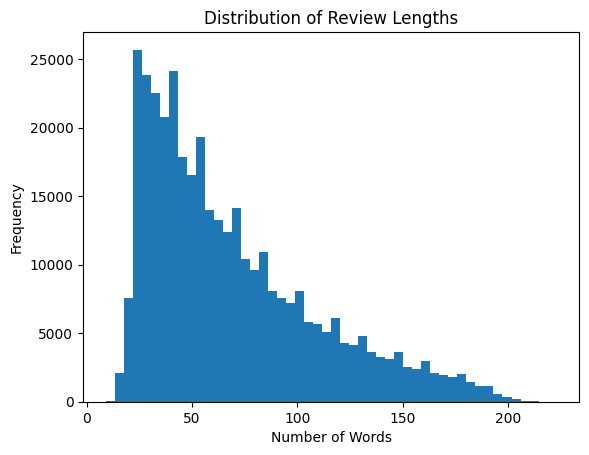

In [99]:
df["review_length"] = df["review"].apply(lambda x: len(x.split()))

plt.hist(df["review_length"], bins=50)

plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

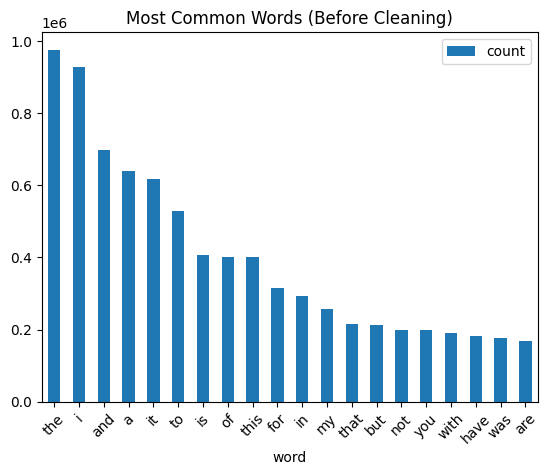

In [100]:
from collections import Counter

words = " ".join(df["review"]).split()
common_words = Counter(words).most_common(20)

words_df = pd.DataFrame(common_words, columns=["word","count"])

words_df.plot(kind="bar", x="word", y="count")

plt.title("Most Common Words (Before Cleaning)")
plt.xticks(rotation=45)
plt.show()

**Data Cleaning**

Create Cleaned pipeline dataset

-lowercase

-remove HTML

-remove punctuation and numbers

-remove extra spaces

In [103]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["review"] = df["review"].apply(clean_text)

In [104]:
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from collections import Counter

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [105]:
stop_words = set(stopwords.words("english"))
stop_words.add("br")  # remove leftover html token

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Remove standalone 'br'
    text = re.sub(r'\bbr\b', ' ', text)

    # Remove non-letters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Normalize spaces
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()

    # Remove stopwords + lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(words)

In [107]:
stop_words.add("br")

In [108]:
from collections import Counter

all_words = " ".join(df["clean_review"]).split()
Counter(all_words).most_common(20)

[('great', 150397),
 ('like', 150093),
 ('good', 149971),
 ('taste', 139247),
 ('product', 119695),
 ('love', 115491),
 ('flavor', 109292),
 ('one', 102184),
 ('coffee', 98716),
 ('tea', 94476),
 ('best', 67673),
 ('would', 65096),
 ('get', 64164),
 ('food', 64000),
 ('make', 63385),
 ('really', 58405),
 ('price', 56075),
 ('time', 55319),
 ('amazon', 54888),
 ('much', 51812)]

In [113]:
print(df["clean_review"].str.contains("br").sum())

81539


In [111]:
df_clean = df.copy()

df_clean["review"] = df_clean["review"].apply(clean_text)

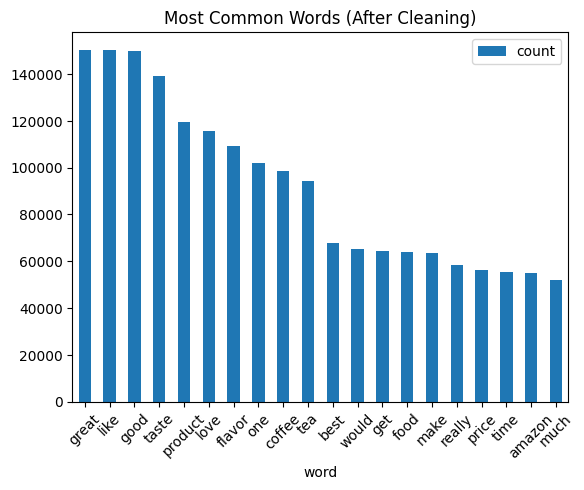

In [121]:
words_clean = " ".join(df_clean["review"]).split()
common_words_clean = Counter(words_clean).most_common(20)

words_clean_df = pd.DataFrame(common_words_clean, columns=["word","count"])

words_clean_df.plot(kind="bar", x="word", y="count")

plt.title("Most Common Words (After Cleaning)")
plt.xticks(rotation=45)
plt.show()

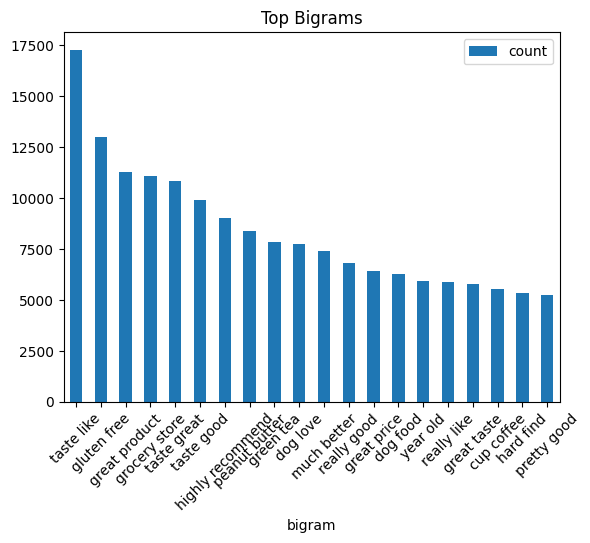

In [115]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)
X_bigrams = vectorizer.fit_transform(df_clean["review"])

bigram_counts = X_bigrams.toarray().sum(axis=0)
bigrams = vectorizer.get_feature_names_out()

bigram_df = pd.DataFrame({"bigram":bigrams,"count":bigram_counts})
bigram_df = bigram_df.sort_values(by="count", ascending=False)

bigram_df.plot(kind="bar", x="bigram", y="count")

plt.title("Top Bigrams")
plt.xticks(rotation=45)
plt.show()

**Handle Negation**:This phase helps the model distinguish from a word like "good" and "not good"

In [ ]:
negation_words = {"not", "no", "never", "n't"}

def handle_negation(text):
    words = text.split()
    result = []
    negate = False

    for word in words:
        if word in negation_words:
            negate = True
            result.append(word)
            continue

        if negate:
            result.append("not_" + word)
            negate = False
        else:
            result.append(word)

    return " ".join(result)

df["review"] = df["review"].apply(handle_negation)

**Removal of Duplicate Reviews**

In [ ]:
print("Before removing duplicates:", df.shape)

df = df.drop_duplicates(subset=["review"])

print("After removing duplicates:", df.shape)

Before removing duplicates: (568427, 3)
After removing duplicates: (394438, 3)


**Removal of very short and long reviews**

In [ ]:
df["review_length"] = df["review"].str.len()

df = df[df["review_length"] > 50]
df = df[df["review_length"] < 1000]

df = df[['review', 'sentiment']]

print(df.shape)

(366476, 2)


**Data Set Balancing**

In [ ]:
def balance_dataset(dataframe):
    positive = dataframe[dataframe["sentiment"] == "positive"]
    neutral = dataframe[dataframe["sentiment"] == "neutral"]
    negative = dataframe[dataframe["sentiment"] == "negative"]

    min_size = min(len(positive), len(neutral), len(negative))

    positive_sample = positive.sample(min_size, random_state=42)
    neutral_sample = neutral.sample(min_size, random_state=42)
    negative_sample = negative.sample(min_size, random_state=42)

    balanced_df = pd.concat([positive_sample, neutral_sample, negative_sample])
    balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

    return balanced_df

In [ ]:
df_base_bal = balance_dataset(df_base)
df_clean_bal = balance_dataset(df_clean)

print("Baseline balanced:")
print(df_base_bal["sentiment"].value_counts())

print("\nCleaned balanced:")
print(df_clean_bal["sentiment"].value_counts())

Baseline balanced:
sentiment
positive    42638
negative    42638
neutral     42638
Name: count, dtype: int64

Cleaned balanced:
sentiment
positive    42638
negative    42638
neutral     42638
Name: count, dtype: int64


**Split into training and testing set**

Baseline

In [ ]:
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    df_base_bal["review"],
    df_base_bal["sentiment"],
    test_size=0.2,
    stratify=df_base_bal["sentiment"],
    random_state=42
)

Cleaned

In [ ]:
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    df_clean_bal["review"],
    df_clean_bal["sentiment"],
    test_size=0.2,
    stratify=df_clean_bal["sentiment"],
    random_state=42
)

**Build Vectorizer for Baseline pipeline**

1. Bag of Words: For Naive Bayes



In [ ]:
bow_base = CountVectorizer(
    stop_words="english",
    min_df=2
)

X_train_base_bow = bow_base.fit_transform(X_train_base)
X_test_base_bow = bow_base.transform(X_test_base)

2.TF-IDF with n-grams and zipf filtering for Logistic Regression and SVM

In [ ]:
tfidf_base = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=2
)

X_train_base_tfidf = tfidf_base.fit_transform(X_train_base)
X_test_base_tfidf = tfidf_base.transform(X_test_base)

**Build Vectorizer for Cleaned pipeline**

1. Bag of Words: For Naive Bayes



In [ ]:
bow_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=3,
    max_df=0.85,
    max_features=50000
)

X_train_clean_bow = bow_vectorizer.fit_transform(X_train_clean)
X_test_clean_bow = bow_vectorizer.transform(X_test_clean)

print("BoW Train size:", X_train_clean_bow.shape)
print("BoW Test size:", X_test_clean_bow.shape)

BoW Train size: (102331, 50000)
BoW Test size: (25583, 50000)


2. TF-IDF with n-grams and zipf filtering for Logistic Regression and SVM

In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=3,
    max_df=0.85,
    max_features=50000,
    sublinear_tf=True
)

X_train_clean_tfidf = tfidf_vectorizer.fit_transform(X_train_clean)
X_test_clean_tfidf = tfidf_vectorizer.transform(X_test_clean)

print("TF-IDF Train size:", X_train_clean_tfidf.shape)
print("TF-IDF Test size:", X_test_clean_tfidf.shape)

TF-IDF Train size: (102331, 50000)
TF-IDF Test size: (25583, 50000)


**Training Supervised Model**

In [ ]:
def run_models(
    pipeline_name,
    X_train_bow,
    X_test_bow,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
):

    results = []

    classes = ["negative","neutral","positive"]

    # -------------------
    # Naive Bayes
    # -------------------

    nb = MultinomialNB()
    nb.fit(X_train_bow, y_train)

    pred_nb = nb.predict(X_test_bow)
    prob_nb = nb.predict_proba(X_test_bow)

    acc_nb = accuracy_score(y_test, pred_nb)

    cm = confusion_matrix(y_test, pred_nb, labels=classes)

    pos_index = classes.index("positive")

    TP = cm[pos_index,pos_index]
    FN = cm[pos_index].sum() - TP
    FP = cm[:,pos_index].sum() - TP
    TN = cm.sum() - (TP + FN + FP)

    ll = log_loss(y_test, prob_nb)

    y_test_bin = label_binarize(y_test, classes=classes)
    roc = roc_auc_score(y_test_bin, prob_nb, multi_class="ovr")

    print("\n",pipeline_name," - Naive Bayes")
    print("Accuracy:",acc_nb)
    print("ROC-AUC:",roc)
    print("Log Loss:",ll)
    print("TP:",TP," FN:",FN," FP:",FP," TN:",TN)
    print(classification_report(y_test,pred_nb))

    results.append({
        "Pipeline":pipeline_name,
        "Model":"Naive Bayes",
        "Accuracy":acc_nb,
        "ROC_AUC":roc,
        "Log_Loss":ll,
        "TP":TP,
        "FN":FN,
        "FP":FP,
        "TN":TN
    })


    # -------------------
    # Logistic Regression
    # -------------------

    lr = LogisticRegression(
    penalty="l2",
    multi_class="multinomial",
    solver="lbfgs",
    C=1.5,
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)
    lr.fit(X_train_tfidf,y_train)

    pred_lr = lr.predict(X_test_tfidf)
    prob_lr = lr.predict_proba(X_test_tfidf)

    acc_lr = accuracy_score(y_test,pred_lr)

    cm = confusion_matrix(y_test,pred_lr,labels=classes)

    TP = cm[pos_index,pos_index]
    FN = cm[pos_index].sum() - TP
    FP = cm[:,pos_index].sum() - TP
    TN = cm.sum() - (TP + FN + FP)

    ll = log_loss(y_test,prob_lr)

    roc = roc_auc_score(y_test_bin,prob_lr,multi_class="ovr")

    print("\n",pipeline_name," - Logistic Regression")
    print("Accuracy:",acc_lr)
    print("ROC-AUC:",roc)
    print("Log Loss:",ll)
    print("TP:",TP," FN:",FN," FP:",FP," TN:",TN)
    print(classification_report(y_test,pred_lr))

    results.append({
        "Pipeline":pipeline_name,
        "Model":"Logistic Regression",
        "Accuracy":acc_lr,
        "ROC_AUC":roc,
        "Log_Loss":ll,
        "TP":TP,
        "FN":FN,
        "FP":FP,
        "TN":TN
    })


    # -------------------
    # SVM
    # -------------------

    svm = LinearSVC(
        class_weight="balanced",
        random_state=42
    )

    svm.fit(X_train_tfidf,y_train)

    pred_svm = svm.predict(X_test_tfidf)

    acc_svm = accuracy_score(y_test,pred_svm)

    cm = confusion_matrix(y_test,pred_svm,labels=classes)

    TP = cm[pos_index,pos_index]
    FN = cm[pos_index].sum() - TP
    FP = cm[:,pos_index].sum() - TP
    TN = cm.sum() - (TP + FN + FP)

    print("\n",pipeline_name," - SVM")
    print("Accuracy:",acc_svm)
    print("TP:",TP," FN:",FN," FP:",FP," TN:",TN)
    print(classification_report(y_test,pred_svm))

    results.append({
        "Pipeline":pipeline_name,
        "Model":"SVM",
        "Accuracy":acc_svm,
        "ROC_AUC":None,
        "Log_Loss":None,
        "TP":TP,
        "FN":FN,
        "FP":FP,
        "TN":TN
    })

    return results

In [ ]:
lr_multi = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    C = 1.5,
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

lr_multi.fit(X_train_base_tfidf, y_train_base)

pred_multi = lr_multi.predict(X_test_base_tfidf)

acc_multi = accuracy_score(y_test_base, pred_multi)

print("Multinomial Logistic Regression Accuracy:", acc_multi)
print(classification_report(y_test_base, pred_multi))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Multinomial Logistic Regression Accuracy: 0.8074893483954189
              precision    recall  f1-score   support

    negative       0.82      0.82      0.82      8527
     neutral       0.75      0.75      0.75      8528
    positive       0.85      0.86      0.86      8528

    accuracy                           0.81     25583
   macro avg       0.81      0.81      0.81     25583
weighted avg       0.81      0.81      0.81     25583



**Evaluation of the Supervised Model**


Baseline Result

In [ ]:
baseline_results = run_models(
    "Baseline",
    X_train_base_bow,
    X_test_base_bow,
    X_train_base_tfidf,
    X_test_base_tfidf,
    y_train_base,
    y_test_base
)


 Baseline  - Naive Bayes
Accuracy: 0.7085564632763944
ROC-AUC: 0.8558775780302538
Log Loss: 1.2897469956775156
TP: 6800  FN: 1728  FP: 1920  TN: 15135
              precision    recall  f1-score   support

    negative       0.73      0.69      0.71      8527
     neutral       0.62      0.63      0.63      8528
    positive       0.78      0.80      0.79      8528

    accuracy                           0.71     25583
   macro avg       0.71      0.71      0.71     25583
weighted avg       0.71      0.71      0.71     25583



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



 Baseline  - Logistic Regression
Accuracy: 0.8074893483954189
ROC-AUC: 0.9328913092340282
Log Loss: 0.5064727294809402
TP: 7348  FN: 1180  FP: 1274  TN: 15781
              precision    recall  f1-score   support

    negative       0.82      0.82      0.82      8527
     neutral       0.75      0.75      0.75      8528
    positive       0.85      0.86      0.86      8528

    accuracy                           0.81     25583
   macro avg       0.81      0.81      0.81     25583
weighted avg       0.81      0.81      0.81     25583


 Baseline  - SVM
Accuracy: 0.8130008208576007
TP: 7468  FN: 1060  FP: 1384  TN: 15671
              precision    recall  f1-score   support

    negative       0.82      0.83      0.82      8527
     neutral       0.77      0.74      0.75      8528
    positive       0.84      0.88      0.86      8528

    accuracy                           0.81     25583
   macro avg       0.81      0.81      0.81     25583
weighted avg       0.81      0.81      0.81   

Cleaned Pipelined Result

In [ ]:
cleaned_results = run_models(
    "Cleaned",
    X_train_clean_bow,
    X_test_clean_bow,
    X_train_clean_tfidf,
    X_test_clean_tfidf,
    y_train_clean,
    y_test_clean
)


 Cleaned  - Naive Bayes
Accuracy: 0.7361529140444827
ROC-AUC: 0.879110610396975
Log Loss: 1.6854538680757802
TP: 7169  FN: 1359  FP: 1964  TN: 15091
              precision    recall  f1-score   support

    negative       0.76      0.72      0.74      8527
     neutral       0.66      0.65      0.66      8528
    positive       0.78      0.84      0.81      8528

    accuracy                           0.74     25583
   macro avg       0.73      0.74      0.73     25583
weighted avg       0.73      0.74      0.73     25583



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



 Cleaned  - Logistic Regression
Accuracy: 0.7936129460970176
ROC-AUC: 0.9250836178191202
Log Loss: 0.523626418572675
TP: 7267  FN: 1261  FP: 1335  TN: 15720
              precision    recall  f1-score   support

    negative       0.81      0.80      0.80      8527
     neutral       0.73      0.73      0.73      8528
    positive       0.84      0.85      0.85      8528

    accuracy                           0.79     25583
   macro avg       0.79      0.79      0.79     25583
weighted avg       0.79      0.79      0.79     25583


 Cleaned  - SVM
Accuracy: 0.7941992729546965
TP: 7292  FN: 1236  FP: 1375  TN: 15680
              precision    recall  f1-score   support

    negative       0.80      0.81      0.80      8527
     neutral       0.74      0.72      0.73      8528
    positive       0.84      0.86      0.85      8528

    accuracy                           0.79     25583
   macro avg       0.79      0.79      0.79     25583
weighted avg       0.79      0.79      0.79     2

In [ ]:
results_df = pd.DataFrame(baseline_results + cleaned_results)

print(results_df)

   Pipeline                Model  Accuracy   ROC_AUC  Log_Loss    TP    FN  \
0  Baseline          Naive Bayes  0.708556  0.855878  1.289747  6800  1728   
1  Baseline  Logistic Regression  0.807489  0.932891  0.506473  7348  1180   
2  Baseline                  SVM  0.813001       NaN       NaN  7468  1060   
3   Cleaned          Naive Bayes  0.736153  0.879111  1.685454  7169  1359   
4   Cleaned  Logistic Regression  0.793613  0.925084  0.523626  7267  1261   
5   Cleaned                  SVM  0.794199       NaN       NaN  7292  1236   

     FP     TN  
0  1920  15135  
1  1274  15781  
2  1384  15671  
3  1964  15091  
4  1335  15720  
5  1375  15680  


In [122]:
results_df.to_csv("model_pipeline_comparison.csv",index=False)

In [123]:
results_df = pd.DataFrame([
    ["Baseline","Naive Bayes",0.7086,0.8559,1.2897],
    ["Baseline","Logistic Regression",0.8075,0.9329,0.5065],
    ["Baseline","SVM",0.8130,None,None],
    ["Cleaned","Naive Bayes",0.7362,0.8791,1.6855],
    ["Cleaned","Logistic Regression",0.7936,0.9251,0.5236],
    ["Cleaned","SVM",0.7942,None,None],
], columns=["Pipeline","Model","Accuracy","ROC_AUC","Log_Loss"])

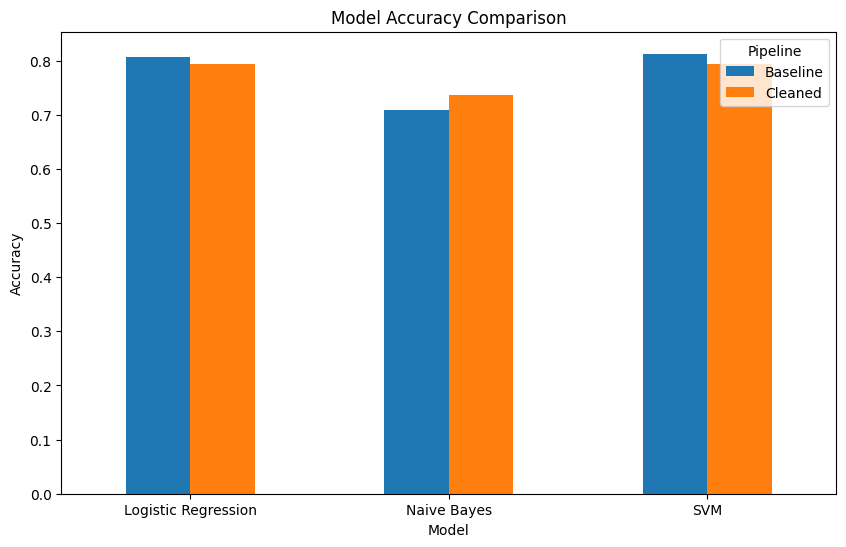

In [124]:
pivot_acc = results_df.pivot(index="Model", columns="Pipeline", values="Accuracy")

pivot_acc.plot(kind="bar", figsize=(10,6))

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.legend(title="Pipeline")

plt.show()

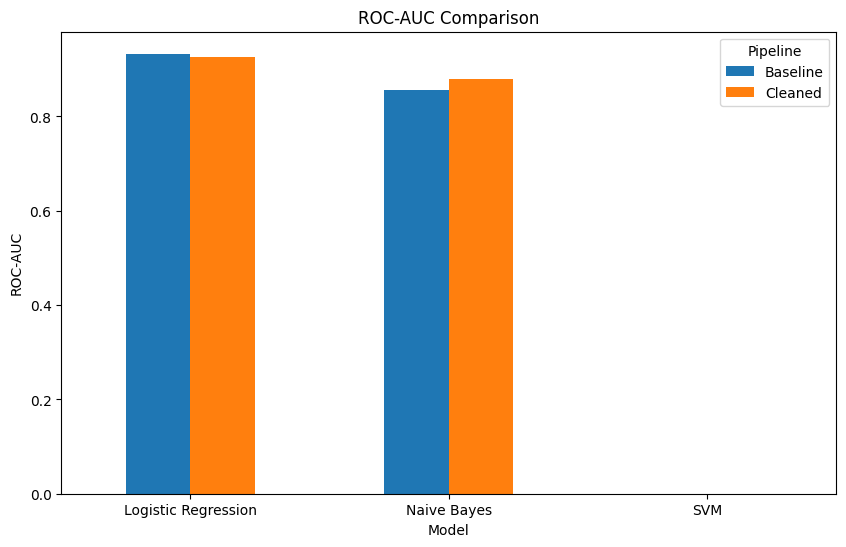

In [125]:
pivot_roc = results_df.pivot(index="Model", columns="Pipeline", values="ROC_AUC")

pivot_roc.plot(kind="bar", figsize=(10,6))

plt.title("ROC-AUC Comparison")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=0)

plt.show()

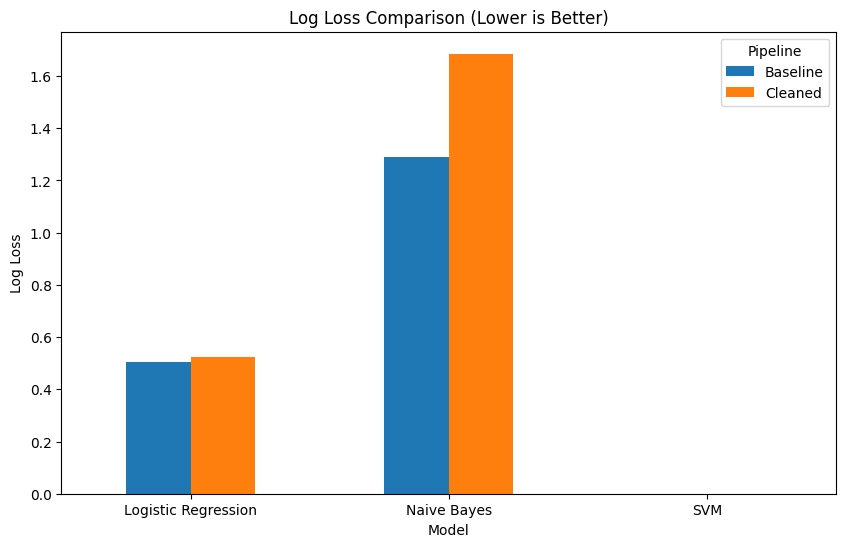

In [126]:
pivot_ll = results_df.pivot(index="Model", columns="Pipeline", values="Log_Loss")

pivot_ll.plot(kind="bar", figsize=(10,6))

plt.title("Log Loss Comparison (Lower is Better)")
plt.ylabel("Log Loss")
plt.xticks(rotation=0)

plt.show()

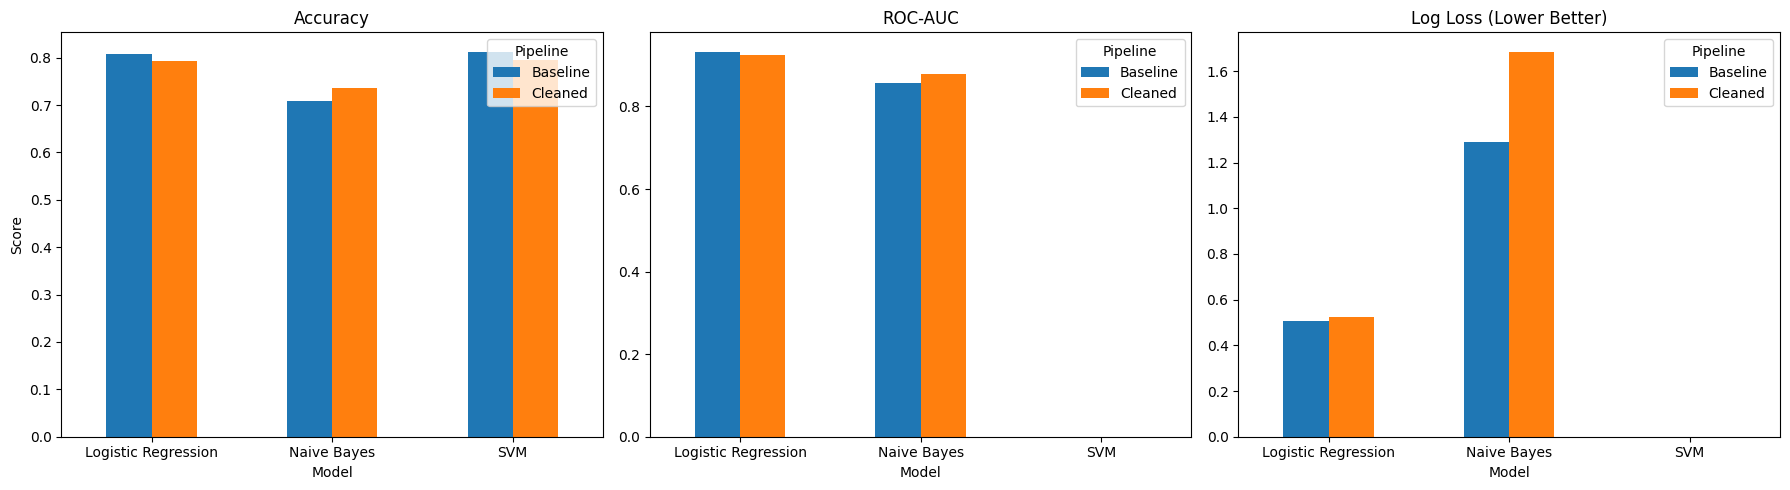

In [127]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

# Accuracy
pivot_acc.plot(kind="bar", ax=axes[0])
axes[0].set_title("Accuracy")
axes[0].set_ylabel("Score")

# ROC-AUC
pivot_roc.plot(kind="bar", ax=axes[1])
axes[1].set_title("ROC-AUC")

# Log Loss
pivot_ll.plot(kind="bar", ax=axes[2])
axes[2].set_title("Log Loss (Lower Better)")

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

**Get Multiple class Probabilities**

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    penalty="l2",
    multi_class = "multinomial",
    solver="lbfgs",
    C=1.5,
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

lr.fit(X_train_base_tfidf, y_train_base)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=1.5, class_weight='balanced', max_iter=2000,
                   multi_class='multinomial', random_state=42)

In [ ]:
prob_lr = lr.predict_proba(X_test_base_tfidf)

Identify positive class index

In [ ]:
positive_index = list(lr.classes_).index("positive")
print(lr.classes_)

['negative' 'neutral' 'positive']


Extract postive probabilities

In [ ]:
positive_probs = prob_lr[:, positive_index]

Convert labels to binary

In [ ]:
y_true_binary = np.where(y_test_base == "positive", 1, 0)

In [128]:
thresholds = np.arange(0.1,0.9,0.05)

rows = []

for t in thresholds:

    preds = (positive_probs >= t).astype(int)

    TP = np.sum((preds == 1) & (y_true_binary == 1))
    TN = np.sum((preds == 0) & (y_true_binary == 0))
    FP = np.sum((preds == 1) & (y_true_binary == 0))
    FN = np.sum((preds == 0) & (y_true_binary == 1))

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    rows.append({
        "threshold":t,
        "TP":TP,
        "TN":TN,
        "FP":FP,
        "FN":FN,
        "precision":precision,
        "recall":recall,
        "f1":f1
    })

threshold_table = pd.DataFrame(rows)

threshold_table

,threshold,TP,TN,FP,FN,precision,recall,f1
0,0.10,8345,10473,6582,183,0.559054,0.978541,0.711575
1,0.15,8232,12389,4666,296,0.638238,0.965291,0.768412
2,0.20,8107,13563,3492,421,0.698940,0.950633,0.805585
3,0.25,7957,14376,2679,571,0.748120,0.933044,0.830411
4,0.30,7804,14935,2120,724,0.786376,0.915103,0.845870
5,0.35,7631,15328,1727,897,0.815452,0.894817,0.853293
6,0.40,7430,15633,1422,1098,0.839358,0.871248,0.855006
7,0.45,7238,15911,1144,1290,0.863517,0.848734,0.856062
8,0.50,7009,16133,922,1519,0.883747,0.821881,0.851692
9,0.55,6763,16296,759,1765,0.899096,0.793035,0.842741


Test Multiple Thresholds

In [ ]:
threshold_table.sort_values("f1", ascending=False)

,threshold,TP,TN,FP,FN,precision,recall,f1
7,0.45,7238,15911,1144,1290,0.863517,0.848734,0.856062
6,0.40,7430,15633,1422,1098,0.839358,0.871248,0.855006
5,0.35,7631,15328,1727,897,0.815452,0.894817,0.853293
8,0.50,7009,16133,922,1519,0.883747,0.821881,0.851692
4,0.30,7804,14935,2120,724,0.786376,0.915103,0.845870
9,0.55,6763,16296,759,1765,0.899096,0.793035,0.842741
3,0.25,7957,14376,2679,571,0.748120,0.933044,0.830411
10,0.60,6480,16444,611,2048,0.913834,0.759850,0.829759
11,0.65,6160,16588,467,2368,0.929531,0.722326,0.812933
2,0.20,8107,13563,3492,421,0.698940,0.950633,0.805585


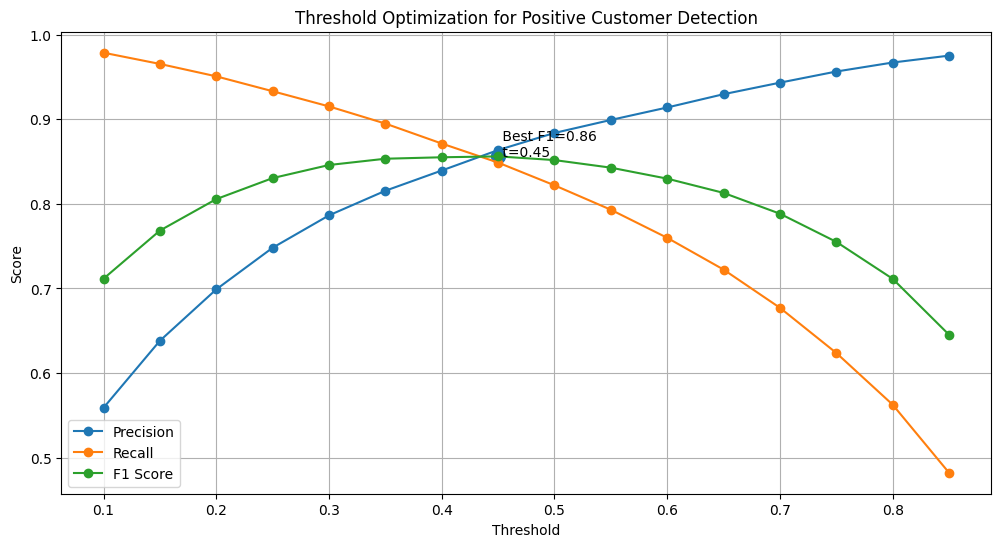

In [129]:
plt.figure(figsize=(12,6))

plt.plot(threshold_table["threshold"], threshold_table["precision"], marker='o', label="Precision")
plt.plot(threshold_table["threshold"], threshold_table["recall"], marker='o', label="Recall")
plt.plot(threshold_table["threshold"], threshold_table["f1"], marker='o', label="F1 Score")

# highlight best F1
best_idx = threshold_table["f1"].idxmax()
best_t = threshold_table.loc[best_idx, "threshold"]
best_f1 = threshold_table.loc[best_idx, "f1"]

plt.scatter(best_t, best_f1, s=100)
plt.text(best_t, best_f1, f" Best F1={best_f1:.2f}\n t={best_t:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization for Positive Customer Detection")

plt.legend()
plt.grid(True)

plt.show()

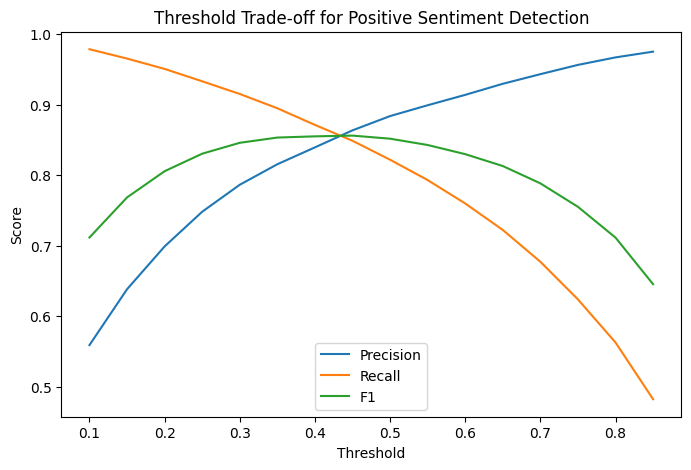

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(threshold_table["threshold"], threshold_table["precision"], label="Precision")
plt.plot(threshold_table["threshold"], threshold_table["recall"], label="Recall")
plt.plot(threshold_table["threshold"], threshold_table["f1"], label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Trade-off for Positive Sentiment Detection")

plt.legend()
plt.show()

In [80]:

from sklearn.metrics import confusion_matrix

# classes must match your training
classes = ["negative", "neutral", "positive"]

# get probabilities
prob_lr = lr.predict_proba(X_test_base_tfidf)

# index for negative class
neg_index = classes.index("negative")

# probability of negative
prob_negative = prob_lr[:, neg_index]

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    # predict negative vs rest
    pred_neg = (prob_negative >= t).astype(int)

    # true labels: 1 if negative else 0
    y_true_neg = (y_test_base == "negative").astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true_neg, pred_neg).ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    results.append([t, tp, tn, fp, fn, precision, recall, f1])

threshold_df = pd.DataFrame(
    results,
    columns=["threshold", "TP", "TN", "FP", "FN", "precision", "recall", "f1"]
)

threshold_df

,threshold,TP,TN,FP,FN,precision,recall,f1
0,0.10,8335,9457,7599,192,0.523095,0.977483,0.681493
1,0.15,8174,11523,5533,353,0.596338,0.958602,0.735270
2,0.20,8012,12793,4263,515,0.652709,0.939604,0.770311
3,0.25,7807,13689,3367,720,0.698675,0.915562,0.792549
4,0.30,7596,14371,2685,931,0.738839,0.890817,0.807741
5,0.35,7393,14919,2137,1134,0.775761,0.867011,0.818851
6,0.40,7143,15326,1730,1384,0.805026,0.837692,0.821034
7,0.45,6864,15662,1394,1663,0.831194,0.804972,0.817873
8,0.50,6546,15944,1112,1981,0.854792,0.767679,0.808897
9,0.55,6233,16160,896,2294,0.874316,0.730972,0.796244


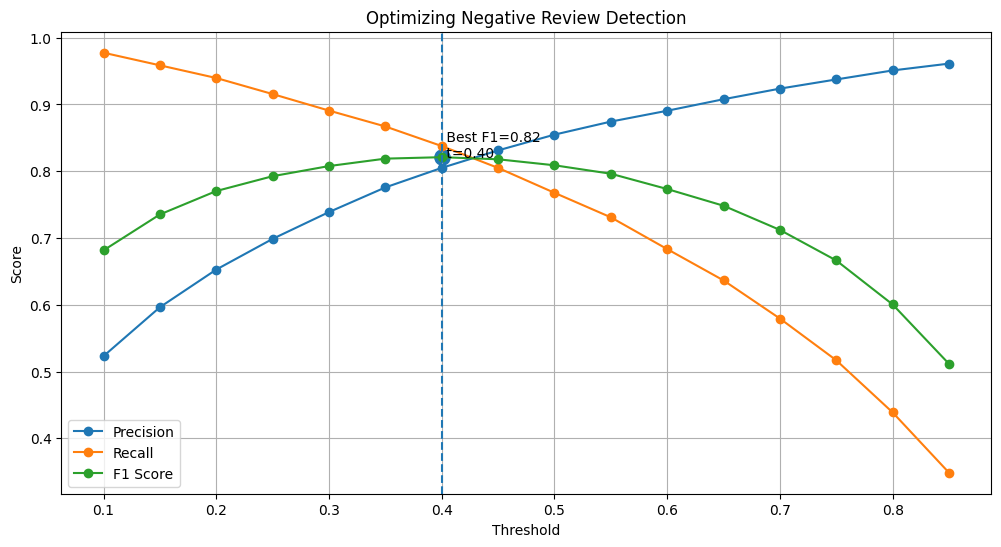

In [130]:
plt.figure(figsize=(12,6))

plt.plot(threshold_df["threshold"], threshold_df["precision"], marker='o', label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker='o', label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker='o', label="F1 Score")

# Highlight best F1
best_idx = threshold_df["f1"].idxmax()
best_t = threshold_df.loc[best_idx, "threshold"]
best_f1 = threshold_df.loc[best_idx, "f1"]

plt.scatter(best_t, best_f1, s=120)
plt.axvline(best_t, linestyle='--')
plt.text(best_t, best_f1, f" Best F1={best_f1:.2f}\n t={best_t:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Optimizing Negative Review Detection")

plt.legend()
plt.grid(True)

plt.show()

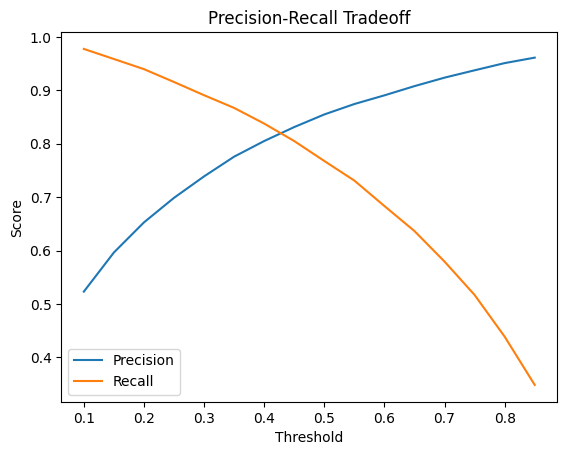

In [116]:
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Tradeoff")
plt.legend()
plt.show()

**Use of subset data for kmeans**

In [86]:
df_cluster = df_base_bal.sample(20000, random_state=42)

Vectorize text (TF-IDF)

In [87]:
tfidf_cluster = TfidfVectorizer(
    stop_words="english",
    min_df=10,
    max_df=0.8,
    ngram_range=(1,2)
)
df_cluster['clean_review'] = df_cluster["review"].apply(clean_text)
X_cluster = tfidf_cluster.fit_transform(df_cluster["clean_review"])

In [88]:
from sklearn.cluster import KMeans

k = 5

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

kmeans.fit(X_cluster)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [89]:
df_cluster["cluster"] = kmeans.labels_

In [90]:
terms = tfidf_cluster.get_feature_names_out()
centroids = kmeans.cluster_centers_

for i in range(k):
    print(f"\nCluster {i}:")

    top_indices = centroids[i].argsort()[-10:][::-1]
    top_words = [terms[j] for j in top_indices]

    print(top_words)


Cluster 0:
['tea', 'green', 'green tea', 'taste', 'flavor', 'like', 'bag', 'tea bag', 'good', 'chai']

Cluster 1:
['taste', 'product', 'like', 'good', 'flavor', 'great', 'love', 'chocolate', 'really', 'buy']

Cluster 2:
['coffee', 'cup', 'flavor', 'like', 'taste', 'roast', 'pod', 'good', 'strong', 'bold']

Cluster 3:
['cat', 'food', 'cat food', 'eat', 'cat love', 'treat', 'love', 'like', 'cat eat', 'ingredient']

Cluster 4:
['dog', 'treat', 'food', 'dog love', 'dog food', 'love', 'chew', 'like', 'toy', 'product']


**Create Cluster Naming Dictionary Based on Top Words**

In [91]:
cluster_names = {
    0: "Tea Products",
    1: "Coffee Products",
    2: "Pet Products",
    3: "Snacks & Sweets",
    4: "General Product Reviews",
}


In [92]:
df_cluster["cluster_name"] = df_cluster["cluster"].map(cluster_names)

In [93]:
cluster_summary = df_cluster.groupby("cluster_name").size().reset_index(name="count")
print(cluster_summary)

              cluster_name  count
0          Coffee Products  14584
1  General Product Reviews   1469
2             Pet Products   2090
3          Snacks & Sweets    648
4             Tea Products   1209


In [94]:
for i in range(k):

    print(f"\nCluster {i} → {cluster_names[i]} SAMPLE REVIEWS:\n")

    print(df_cluster[df_cluster["cluster"] == i]["review"].head(3))


Cluster 0 → Tea Products SAMPLE REVIEWS:

28303     this tea is my hero yoga tea's women's moon cy...
118071    very green, very flavorful! as someone trying ...
127247    it is a waste of money i have been trying to u...
Name: review, dtype: object

Cluster 1 → Coffee Products SAMPLE REVIEWS:

107193    gloria jeans hazelnut k-cups the service was e...
17002     rich chocolate mix the taste of this product i...
114173    totally delicious these bitters give a nice fr...
Name: review, dtype: object

Cluster 2 → Pet Products SAMPLE REVIEWS:

28171     there's a reason the coffee people named this ...
127493    disappointing i am jumping on the bandwagon wi...
41385     so flavorful!!!! i absolutely love the flavor ...
Name: review, dtype: object

Cluster 3 → Snacks & Sweets SAMPLE REVIEWS:

47716     excellent, i think my cat was 20 years old and...
9203      expired product, spoiled item, do not buy i go...
120881    ok cat food for your cats i think it might be ...
Name: review, dtyp

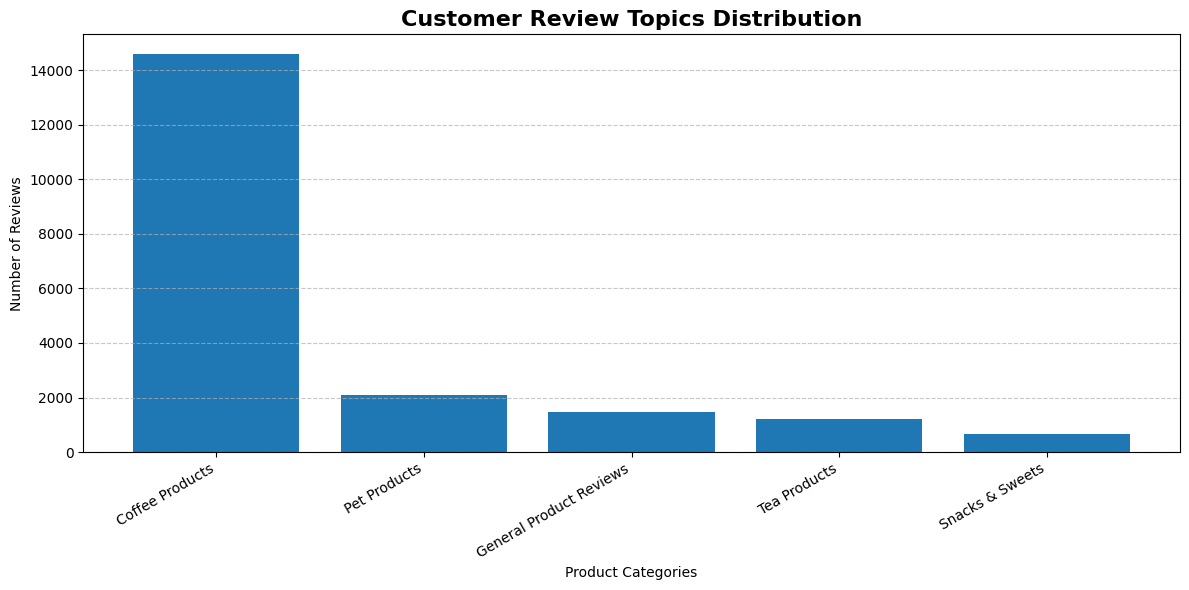

In [95]:
cluster_summary_sorted = cluster_summary.sort_values("count", ascending=False)

plt.figure(figsize=(12,6))

plt.bar(cluster_summary_sorted["cluster_name"], cluster_summary_sorted["count"])

plt.title("Customer Review Topics Distribution", fontsize=16, weight="bold")
plt.ylabel("Number of Reviews")
plt.xlabel("Product Categories")

plt.xticks(rotation=30, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

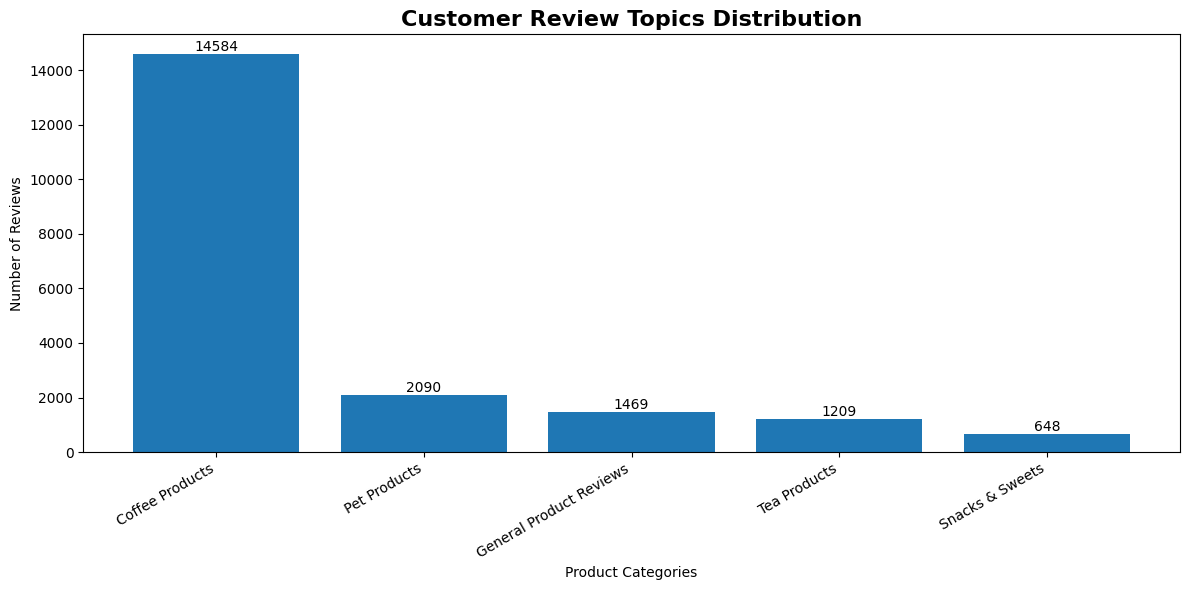

In [96]:
plt.figure(figsize=(12,6))

bars = plt.bar(cluster_summary_sorted["cluster_name"], cluster_summary_sorted["count"])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval),
             ha='center', va='bottom')

plt.title("Customer Review Topics Distribution", fontsize=16, weight="bold")
plt.ylabel("Number of Reviews")
plt.xlabel("Product Categories")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()